Przed oddaniem zadania upewnij się, że wszystko działa poprawnie.
**Uruchom ponownie kernel** (z paska menu: Kernel$\rightarrow$Restart) a następnie
**wykonaj wszystkie komórki** (z paska menu: Cell$\rightarrow$Run All).

Upewnij się, że wypełniłeś wszystkie pola `TU WPISZ KOD` lub `TU WPISZ ODPOWIEDŹ`, oraz
że podałeś swoje imię i nazwisko poniżej:


In [27]:
NAME = "Mateusz Wojtaszek"

---


# 2. Model TNC

Przedstawimy teraz zasadę działania modelu TNC, zaimplementujemy jego najistotniejsze elementy oraz dokonamy ewaluacji modelu.


## 2.1. Idea modelu TNC

Dla ciągu czasowego $X \in \mathbb{R}^{D \times T}$ możemy określić okno przesuwne $X_{[t - \frac{\delta}{2}, t + \frac{\delta}{2}]}$ o długości $\delta$ wycentrowane wokół chwili $t$, które zawiera pomiary wszystkich cech w przedziale czasu $[t - \frac{\delta}{2}, t + \frac{\delta}{2}]$. Dla ułatwienia zapisu okno to będzie oznaczane jako $W_t$.

Celem metody uczenia reprezentacji będzie uzyskanie wektorowej reprezentacji dowolnego okna $W_t$.


### Temporalne sąsiedztwo

Dla okna $W_t$ zdefiniujmy jego temporalne sąsiedztwo $N_t$ jako zbiór wszystkich okien wycentrowanych w $t^*$, gdzie wartość ta jest próbkowana z rozkładu normalnego $t^* \sim \mathcal{N}(t, \eta \cdot \delta)$. Parametr $\eta$ definiuje szerokość / zakres sąsiedztwa temporalnego.

Wybór parametru $\eta$ może być oparty o wiedzę ekspercką, jednak w publikacji autorzy zaproponowali zastosowanie testu statystycznego **Augmented Dickey-Fuller (ADF)**, który będzie sprawdzać stacjonarność rozkładu próbek w sąsiedztwie temporalnym. Algorytm wyboru parametru zakłada, że rozpoczynamy od niewielkiej wartości, po czym iteracyjnie zwiększamy parametr $\eta$, powodując poszerzenie się temporalnego sąsiedztwa. Zwiększanie wartości następuje do momentu aż test statystyczny nie będzie w stanie odrzucić hipotezy zerowej.


### "Uczenie kontrastowe"

Okna w sąsiedztwie temporalnym możemy uznać jako podobne do obecnie rozważanego okna ciągu czasowego. Pozostaje zatem pytanie jak uzyskać przykłady negatywne, tak abyśmy mogli zastosować koncepcję uczenia kontrastowego.

Moglibyśmy założyć, że wszystkie próbki (okna) poza temporalnym sąsiedztwem są przykładami negatywnymi. Może się jednak tak zdarzyć, że nawet bardzo odległe okno, jest w istocie podobne do obecnego (ma taką samą dynamikę zmian / pochodzi z tego samego rozkładu). W takiej sytuacji uczenie modelu nie byłoby efektywne. Autorzy proponują użycie podejścia **Positive-Unlabeled (PU) learning**, w którym mamy próbki bazowe, próbki pozytywne i próbki nieoznaczone. W naszym przykładzie próbkami nieoznaczonymi będą próbki spoza sąsiedztwa temporalnego.

Do próbek nieoznaczonych są przypisywane wagi $w$ (tutaj: hiperparametr metody), a każda próbka nieoznaczona jest traktowana jako połączenie próbki pozytywnej z wagą $w$ oraz próbki negatywnej z wagą $1 - w$. Zobaczymy to dalej w funkcji kosztu.


### Koder i dyskryminator

Model TNC będziemy uczyć za pomocą funkcji kosztu, która pozwala odróżniać reprezentacje próbek z tego samego sąsiedztwa temporalnego od próbek spoza sąsiedztwa.

Pierwszym elementem modelu TNC jest **koder** $\text{Enc}(W_t)$, które przekształca okno $W_t \in \mathbb{R}^{D \times \delta}$ w wektor reprezentacji $Z_t \in \mathbb{R}^M$.

Drugim elementem jest **dyskryminator** $\mathcal{D}(Z_t, Z)$ pozwalający aproksymować prawdopodobieństwo tego, że $Z$ jest reprezentacją okna w sąsiedztwie $N_t$. Innymi słowy, dla dwóch wektorów reprezentacji zwraca prawdopodobieństwo tego, że te wektory (okna) należą do tego samego sąsiedztwa temporalnego.


Przeanalizujmy rysunek przedstawiający zasadę działania modelu TNC:

![](./assets/tnc.png)


### Funkcja kosztu

W najlepszym przypadku dyskryminator powinien zwracać wartości bliskie 1 dla reprezentacji z tego samego temporalnego sąsiedztwa oraz wartość 0 w przeciwnym przypadku. Funkcja kosztu jest zdefiniowana następująco:

$$\mathcal{L} = -\mathbb{E}_{W_t\sim X}\left[ \mathbb{E}_{W_l \sim N_t}[\log \mathcal{D}(Z_t,Z_l)] +\mathbb{E}_{W_k \sim \bar{N}_t}[(1-w_t)\times \log(1 - \mathcal{D}(Z_t, Z_k)) + w_t\times \log\mathcal{D}(Z_t, Z_k)] \right]$$


## 2.2. Implementacja kodera

Ze względu na sekwencyjny charakter próbek w oknie, jako model kodera użyjemy dwukierunkowej sieci rekurencyjnego typu GRU, która na wyjściu cechy przekształci dodatkową warstwą liniową. Sieć rekurencyjna dostarcza nam stany ukryte w formie wektorów dla każdego punktu wejściowego w sekwencji, więc w celu otrzymania jednego wektora podsumowującego całą sekwencję należy dokonać odpowiedniej agregacji. W niniejszym koderze rozwarzymy dwie metody agregacji sekwencji stanów ukrytych:

- wybór ostatniego stanu ukrytego
- agregacja stanów ukrytych z wykorzystaniem mechanizmu uwagi (ang. _attention_)


## Zadanie 2.1 (1.5 pkt)

Zaimplementuj dwie klasy dla dwóch niżej zdefiniowanych stanów ukrytych:

1. `LastHiddenAggreagation` (0.5 pkt) - metoda `forward(...)` zwraca ostatni stan ukryty z sekwencji (pamiętaj, że jest to sieć dwukierunkowa, więc ostatnie stany ukryte dla każdego z kierunku będą na przeciwnych końcach hidden states)
2. `AttentionAggregation` (1 pkt):
   - aplikuje [_scaled dot product attention_](https://arxiv.org/abs/1706.03762) oraz oblicza średnią z otrzymanych wektorów
   - podpowiedź: możesz wykorzystać `torch.nn.MultiHeadAttention` z parametrem `num_heads=1`, ale **należy mieć zrozumienie i intuicje, jak działa mechanizm uwagi i jak może pomagać w agregacji**


In [28]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F


class LastHiddenAggregation(nn.Module):
    def forward(self, rnn_output: Tensor) -> Tensor:
        """Aggregates information from sequence of vectors by taking last state.
        rnn_output: Tensor with dimensions [sequence_length, batch_size, hidden_dim]
        returns: Tensor with dimensions [batch_size, hidden_dim]
        """
        # TU WPISZ KOD
        half_dim = rnn_output.shape[-1] // 2  # punkt podziału miedzy forward a backward

        forward_last = rnn_output[-1, :, :half_dim]  # dla forward ostatni

        backward_last = rnn_output[0, :, half_dim:]  # dla backward pierwszy

        return torch.cat([forward_last, backward_last], dim=-1)


class AttentionAggregation(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        # TU WPISZ KOD
        self.attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=1)

    def forward(self, rnn_output: Tensor) -> Tensor:
        """Aggregates information from sequence of vectors with scaled-dot-product attention.
        rnn_output: Tensor with dimensions [sequence_length, batch_size, hidden_dim]
        returns: Tensor with dimensions [batch_size, hidden_dim]
        """
        # TU WPISZ KOD
        attn_output, _ = self.attention(rnn_output, rnn_output, rnn_output)
        return attn_output.mean(dim=0)  # dim zero to wzdłóż wymiaru czasu

**Spostrzeżenia**

- Implementacja LastHiddenAggregation wymagała uwzględnienia specyfiki sieci dwukierunkowej, gdzie ostateczny kontekst sekwencji znajduje się na przeciwległych końcach tensora wyjściowego.

- AttentionAggregation pozwala modelowi dynamicznie skupiać się na najważniejszych fragmentach okna czasowego. Mechanizm uwagi ocenia wzajemne relacje między krokami sygnału, co skutkuje znacznie bogatszą i bardziej spójną reprezentacją całego okna


## Zadanie 2.2 (1.5 pkt)

Zaimplementuj klasę `GRUEncoder` zgodnie z poniższymi wymaganiami:

- w metodzie `__init__()`:
  - utwórz instancję sieci GRU o wymiarze wejściowym `in_dim`, wymiarze ukrytym `hidden_dim`, która posiada jedną warstwę oraz jest dwukierunkowa (ustaw dodatkowo parametr `batch_first=False`)
  - utwórz instancję warstwy liniowej o odpowiednim wymiarze wejściowym oraz wyjściu o wymiarowości `emb_dim`
- w metodzie `_get_initial_hidden()` utwórz wektor zer jako początkowy stan ukryty
- w metodzie `forward()` przetwórz cechy okień podanych na wejściu i wyznacz wektory reprezentacji (używając sieci GRU a następnie warstwy liniowej)


In [29]:
from typing import Literal


class GRUEncoder(nn.Module):
    def __init__(
        self,
        agg: Literal["last", "attn"],
        in_dim: int,
        hidden_dim: int,
        emb_dim: int,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.emb_dim = emb_dim

        if agg == "last":
            self.agg = LastHiddenAggregation()
        elif agg == "attn":
            self.agg = AttentionAggregation(2 * hidden_dim)
        else:
            raise ValueError(f"Invalid aggregation name")

        # TU WPISZ KOD
        self.gru = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            bidirectional=True,
            batch_first=False,  # bo w forward jest permute
        )
        # Wejście to stan ukryty w obu kierunkach
        self.linear = nn.Linear(in_features=2 * hidden_dim, out_features=emb_dim)

    def _get_initial_hidden(self, batch_size):
        # TU WPISZ KOD
        # przed bachem nowym zeruje pamięć GRU potrzebuje [liczba_warstw * liczba_kierunków, wielkość_paczki, rozmiar_ukryty]
        return torch.zeros(2, batch_size, self.hidden_dim)

    def forward(self, x):
        # Autorzy kodu dodali na początku x = x.permute(2, 0, 1). Dlaczego?
        # Zwykle dane wprowadzamy w formacie [batch_size, in_dim, seq_length].
        # Jednak domyślnie PyTorchowe RNN i GRU działają szybciej i oczekują formatu [seq_length, batch_size, in_dim].
        # Operacja permute zamienia miejscami wymiary, przygotowując dane pod to optymalne ułożenie.
        x = x.permute(2, 0, 1)

        emb = ...
        # TU WPISZ KOD

        batch_size = x.shape[1]

        # generowanie stanu początkowego
        h0 = self._get_initial_hidden(batch_size).to(x.device)

        rnn_output, _ = self.gru(x, h0)

        # Agragacja do 1 wektora
        agg_output = self.agg(rnn_output)

        # Mapuje zagregowany wektor na docelową przestrzeń embeddingów
        emb = self.linear(agg_output)

        return emb


**Spostrzeżenia**

- Koder oparty na dwukierunkowej sieci GRU przetwarza dane z uwzględnieniem kontekstu przeszłego i przyszłego, dlatego warstwa liniowa musi przyjmować połączony wymiar 2 \* hidden_dim.
- Inicjalizacja stanu ukrytego zerami zapewnia neutralny punkt startowy dla każdego analizowanego okna czasowego


## 2.3. Implementacja dyskryminatora

W przypadku dyskryminatora porównamy dwa proste modele, tak aby nie ryzykować przeuczeniem tego komponentu, tj. iloczyn skalarny i wielowarstwowy perceptron (MLP).


## Zadanie 2.3 (2 pkt)

Zaimplementuj 2 modele dyskryminatora zgodnie z następującymi wymaganiami:

`DotProductDiscriminator` (1 pkt):

- w metodzie `forward()` zwróc iloczyn skalarny odpowiadających sobie reprezentacji (uprzednio znormalizuj reprezentacje do jednostkowej długości)

`MLPDiscriminator` (1 pkt):

- w metodzie `__init__()` utwórz wielowarstwowy perceptron z następującymi warstwami (`d` to wymiar wejściowy):
  - warstwa liniowa o rozmiarach 2*d na 4*d
  - aktywacja ReLU
  - dropout z prawdp. równym 0.5
  - kolejna warstwa liniowa o rozmiarze 4\*d na 1
- w metodzie `forward()` dokonaj konkatenacji reprezentacji `z` oraz `z_tilde` a następnie przekaż je do perceptrona


In [30]:
class DotProductDiscriminator(nn.Module):
    def forward(self, z: Tensor, z_tilde: Tensor) -> Tensor:
        """
        Zwraca iloczyn skalarny znormalizowanych wektorów reprezentacji.
        Normalizacja L2 sprawia, że jest to równoważne podobieństwu cosinusowemu.
        """
        # TU WPISZ KOD
        # normalizacja wektoru do długości jednostkowej wzdłóż wymiaru cech (dim = -1)
        z_norm = F.normalize(z, p=2, dim=-1)
        z_tilde_norm = F.normalize(z_tilde, p=2, dim=-1)

        # iloczyn skalarny
        dot_product = (z_norm * z_tilde_norm).sum(dim=-1)

        return dot_product


class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()

        # TU WPISZ KOD
        self.mlp = nn.Sequential(
            # 2d na 4d
            nn.Linear(in_features=2 * input_dim, out_features=4 * input_dim),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            # 4d na 1
            nn.Linear(in_features=4 * input_dim, out_features=1),
        )

    def forward(self, z: Tensor, z_tilde: Tensor) -> Tensor:
        p = ...
        # TU WPISZ KOD
        # konkatencja i przepuszczenie przez Perceptron
        combined = torch.cat([z, z_tilde], dim=-1)
        p = self.mlp(combined)

        return p.view((-1,))


- DotProductDiscriminator, dzięki normalizacji wektorów, działa jako miernik podobieństwa kosinusowego, który (jak pokazują późniejsze wyniki) wymusza układanie reprezentacji w sposób ułatwiający separację liniową klas.

- MLPDiscriminator, łączący oba wektory i wykorzystujący warstwy ukryte oraz nieliniowość, uczy się znacznie bardziej złożonych relacji, co pozwala na silniejsze grupowanie podobnych fragmentów (kosztem jak sie później okazuje, wydajności w zadaniu prostej klasyfikacji.)


## 2.4. Implementacja funkcji kosztu

W celu implementacji funkcji kosztu możemy wspomóc się gotową funkcją binarnej entropii krzyżowej, zauważając że problem uczenia dyskryminatora (a zatem całego modelu TNC) sprowadza się do problemu klasyfikacji binarnej. **Należy zaimplementować funkcję kosztu w pełnej zgodności ze wzorem podanym w publikacji (i wspomnianym w niniejszym zeszycie)**


## Zadanie 2.4 (3 pkt)

Zaimplementuj moduł implementujący funkcję kosztu modelu TNC stosując następujące wskazówki/instrukcje:

- `z_t` to reprezentacje obecnie rozważanych okien, `z_p` to reprezentacje pozytywne, natomiast `z_n` to reprezentacje nieoznaczone
- najpierw wyznacz predykcje dyskryminatora dla pary `(z_t, z_p)` oraz `(z_t, z_n)`
- przygotuj etykiety (zera i jedynki) dla par podobnych oraz różnych
- oblicz funkcję binarnej entropii krzyżowej dla wyników dyskryminatora, pamiętaj, że:
  - parę `(z_t, z_p)` chcemy traktować jako pozytywną (klasa 1)
  - parę `(z_t, z_n)` chcemy traktować jako pozytywną z wagą `w` oraz jako negatywną (klasa 0) z wagą `1 - w`
- zaimplementuj metodę `_compute_accuracy()`, która sprawdzi czy decyzje dyskryminatora są właściwe (pary pozytywne mają prawdp. `> 0.5`, a pary negatwne `< 0.5`; pamiętaj o zastosowaniu funkcji sigmoid!); wyniki uśrednij uzyskując miarę accuracy


In [31]:
from typing import Tuple


class TNCLossFunction(nn.Module):
    def __init__(self, discriminator: Literal["dot", "mlp"], emb_dim: int, w: float):
        super().__init__()

        if discriminator == "dot":
            self.discriminator = DotProductDiscriminator()
        elif discriminator == "mlp":
            self.discriminator = MLPDiscriminator(input_dim=emb_dim)
        else:
            raise ValueError(f"Invalid discriminator: {discriminator}")

        self.bce = torch.nn.BCEWithLogitsLoss()
        self.w = w

    def forward(
        self,
        z_t: Tensor,
        z_p: Tensor,
        z_n: Tensor,
    ) -> Tuple[Tensor, float]:
        d_p = ...
        d_n = ...
        loss = ...

        # TU WPISZ KOD

        # predykcje dyskryminatora
        d_p = self.discriminator(z_t, z_p)  # prawdziwe pary
        d_n = self.discriminator(z_t, z_n)  # próbki nieoznaczone

        # wektory do porównywania
        ones_p = torch.ones_like(d_p)
        ones_n = torch.ones_like(d_n)
        zeros_n = torch.zeros_like(d_n)

        # loss dla prawdziwych sąsiadów
        loss_p = self.bce(d_p, ones_p)

        #! loss dla nieoznaczonych PU Learning
        # jako przyklad negatywny
        loss_n_neg = self.bce(d_n, zeros_n)
        # jako przykład pozytywny
        loss_n_pos = self.bce(d_n, ones_n)

        # ? ostatecznie jak we wzorze loss dla nieoznaczonych
        loss_n = (1 - self.w) * loss_n_neg + self.w * loss_n_pos

        loss = loss_p + loss_n

        accuracy = self._compute_accuracy(d_p=d_p, d_n=d_n)

        return loss, accuracy

    @staticmethod
    def _compute_accuracy(d_p: Tensor, d_n: Tensor) -> float:
        # TU WPISZ KOD
        # sigmoid -> surowe wartości z Dys na prawdopodobienstwo [0, 1]
        prob_p = torch.sigmoid(d_p)
        prob_n = torch.sigmoid(d_n)

        # zliczanie predykcji, próg 0.5
        correct_p = (prob_p > 0.5).float().sum()
        correct_n = (prob_n < 0.5).float().sum()

        # łączna liczba sprawdzanych próbek (numel = number of elements)
        total_samples = d_p.numel() + d_n.numel()
        # Uśrednione Acc
        acc = (correct_p + correct_n).item() / total_samples

        return acc


## 2.5. Uruchomienie modelu TNC

Poniżej znajduje się kod pozwalający wyuczyć model TNC (implementacja w bibliotece PyTorch-Lightning). Ustawimy domyślny zbiór hiperparametrów i będziemy uczyć model przez 50 epok. Następnie zwizualizujemy otrzymane wektory reprezentacji i zastosujemy je w zadaniu klasyfikacji.


Moduł danych:


In [32]:
import os

import pytorch_lightning as pl
from torch.utils.data import DataLoader

from src.dataset import TNCDataset


class TrainDataModule(pl.LightningDataModule):
    def __init__(
        self,
        mc_sample_size: int,
        window_size: int,
        batch_size: int,
    ):
        super().__init__()

        self.mc_sample_size = mc_sample_size
        self.window_size = window_size
        self.batch_size = batch_size

        self.dataset = torch.load(f="./data/simulated.pt")

    def train_dataloader(self) -> DataLoader:
        return self._dataloader("x_train")

    def val_dataloader(self) -> DataLoader:
        return self._dataloader("x_val", shuffle=False)

    def _dataloader(self, split: str, shuffle: bool = True) -> DataLoader:
        data = TNCDataset(
            x=self.dataset[split],
            mc_sample_size=self.mc_sample_size,
            window_size=self.window_size,
        )
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=int(os.environ.get("NUM_WORKERS", 0)),
        )


Model TNC:


In [33]:
import numpy as np
from typing import Any


class TNCModel(pl.LightningModule):
    def __init__(self, hparams: dict[str, Any]):
        super().__init__()

        self.save_hyperparameters(hparams)

        self.encoder = GRUEncoder(
            agg=hparams["agg"],
            in_dim=hparams["in_dim"],
            hidden_dim=hparams["hidden_dim"],
            emb_dim=hparams["emb_dim"],
        )
        self._loss_fn = TNCLossFunction(
            discriminator=hparams["discriminator"],
            emb_dim=self.encoder.emb_dim,
            w=self.hparams["w"],
        )

        self.training_step_outputs = []
        self.validation_step_outputs = []

    def forward(self, x):
        return self.encoder(x)

    def training_step(self, batch, batch_idx):
        loss, acc = self._common_step(batch)
        return {"loss": loss, "acc": acc}

    def validation_step(self, batch, batch_idx):
        loss, acc = self._common_step(batch)
        return {"loss": loss, "acc": acc}

    def on_train_batch_end(self, outputs, batch, batch_idx) -> None:
        self.training_step_outputs.append(outputs)

    def on_validation_batch_end(self, outputs, batch, batch_idx) -> None:
        self.validation_step_outputs.append(outputs)

    def on_validation_epoch_start(self):
        avg_loss, avg_accs = self._summarize_outputs(self.training_step_outputs)
        self.training_step_outputs = []

        self.log("step", self.trainer.current_epoch)
        self.log("train/loss", avg_loss, on_epoch=True, on_step=False)
        self.log("train/acc", avg_accs, on_epoch=True, on_step=False)

    def on_validation_epoch_end(self):
        avg_loss, avg_accs = self._summarize_outputs(self.validation_step_outputs)
        self.validation_step_outputs = []

        self.log("step", self.trainer.current_epoch)
        self.log("val/loss", avg_loss, on_epoch=True, on_step=False)
        self.log("val/acc", avg_accs, on_epoch=True, on_step=False)

    def _common_step(self, batch):
        x_t, x_p, x_n, _ = batch
        mc_sample = x_p.shape[1]
        batch_size, f_size, len_size = x_t.shape

        x_p = x_p.reshape((-1, f_size, len_size))
        x_n = x_n.reshape((-1, f_size, len_size))
        x_t = x_t.repeat(mc_sample, 1, 1)

        z_t = self.encoder(x_t)
        z_p = self.encoder(x_p)
        z_n = self.encoder(x_n)

        loss, acc = self._loss_fn(z_t=z_t, z_p=z_p, z_n=z_n)

        return loss, acc

    def configure_optimizers(self):
        return torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    @staticmethod
    def _summarize_outputs(outputs):
        losses = [out["loss"].item() for out in outputs]
        accs = [out["acc"] for out in outputs]

        avg_loss = np.mean(losses)
        avg_accs = np.mean(accs)

        return avg_loss, avg_accs

Ustawienie domyślnych hiperparametrów:


In [34]:
default_hparams = {
    "agg": "last",
    "discriminator": "dot",
    "in_dim": 3,
    "hidden_dim": 100,
    "emb_dim": 10,
    "window_size": 50,
    "mc_sample_size": 40,
    "w": 0.05,
    "num_epochs": 50,
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "batch_size": 10,
    "name": "default",
}

Uczenie modelu TNC:


In [35]:
%load_ext tensorboard
%tensorboard --logdir ./data/logs --port 6006

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 125783), started 0:03:12 ago. (Use '!kill 125783' to kill it.)

In [36]:
datamodule = TrainDataModule(
    mc_sample_size=default_hparams["mc_sample_size"],
    window_size=default_hparams["window_size"],
    batch_size=default_hparams["batch_size"],
)
datamodule.setup("train")

In [37]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger


def train(hparams):
    pl.seed_everything(42)

    datamodule = TrainDataModule(
        mc_sample_size=hparams["mc_sample_size"],
        window_size=hparams["window_size"],
        batch_size=hparams["batch_size"],
    )
    tnc = TNCModel(hparams)

    model_chkpt = ModelCheckpoint(
        dirpath=f"./data/checkpoints/{hparams['name']}/",
        filename="model",
        monitor="val/acc",
        mode="max",
        verbose=False,
    )
    trainer = pl.Trainer(
        logger=TensorBoardLogger(
            save_dir="./data/logs",
            name=f"TNC_{hparams['name']}",
            default_hp_metric=False,
        ),
        callbacks=[model_chkpt],
        num_sanity_val_steps=0,
        log_every_n_steps=1,
        max_epochs=hparams["num_epochs"],
        accelerator="cpu",  # change to "cuda", if want to train on GPU
    )

    trainer.fit(model=tnc, datamodule=datamodule)


train(hparams=default_hparams)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops
/home/black-mw/miniconda3/envs/rep_len/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many wo

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Ewaluacja modelu:

- wizualizacja wektorów ukrytych i surowych danych
- zadanie klasyfikacji stanu procesu generującego ciąg czasowy
- zadanie klasteryzacji wektorów reprezentacji


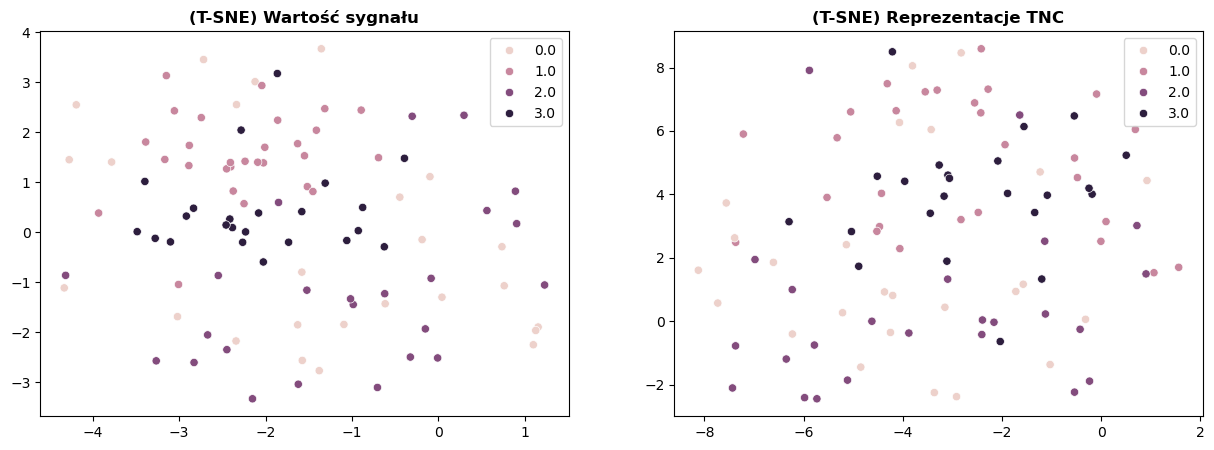

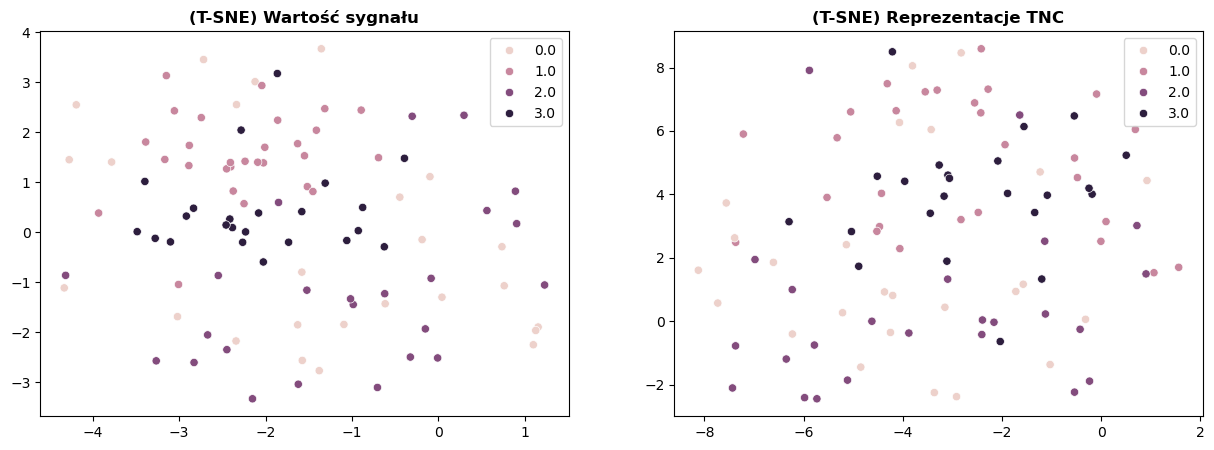

In [38]:
from src.utils import visualize_embeddings
from src.evaluations import evaluate_model


def visualize(name: str):
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model.ckpt"
    )

    best_encoder = best_tnc_model.encoder

    dataset = torch.load("./data/simulated.pt")

    fig = visualize_embeddings(
        x_all=dataset["x_all"],
        y_all=dataset["y_all"],
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )
    return fig


visualize(default_hparams["name"])

In [39]:
def evaluate_classification_clustering(name: str):
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model.ckpt"
    )

    best_encoder = best_tnc_model.encoder

    dataset = torch.load("./data/simulated.pt")

    metrics = evaluate_model(
        dataset=dataset,
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )

    return metrics


evaluate_classification_clustering(default_hparams["name"])

{'auc': {'train': np.float64(0.9139493887916037),
  'val': np.float64(0.8895698304415562),
  'test': np.float64(0.9017250003182531)},
 'cluster': {'silhouette': np.float32(0.1413772),
  'davies_bouldin': np.float64(2.130725787968342)}}

## Zadanie 2.5. Badanie wpływu metody agregacji oraz dyskryminatora TNC (1.5 pkt)

Korzystając z domyślnych hiperparametrów sprawdź, który z zaimplementowanych modułów agregacji oraz dyskryminatora dostarcza najlepszych rezultatów. Sprawdź wszystkie 4 kombinacje $\{\mathrm{last}, \mathrm{attn}\} \times \{\mathrm{dot}, \mathrm{mlp}\}$


In [41]:
# TU WPISZ KOD
import pandas as pd

# Definiujemy opcje do przetestowania
aggregations = ["last", "attn"]
discriminators = ["dot", "mlp"]

# Lista na wyniki
results = []

for agg in aggregations:
    for disc in discriminators:
        # Tworzymy unikalną nazwę dla tej kombinacji, aby wagi się nie nadpisały
        experiment_name = f"{agg}_{disc}"
        print(f"--- Rozpoczynam eksperyment: Agregacja={agg}, Dyskryminator={disc} ---")

        # Kopiujemy domyślne parametry i aktualizujemy badane wartości
        current_hparams = default_hparams.copy()
        current_hparams["agg"] = agg
        current_hparams["discriminator"] = disc
        current_hparams["name"] = experiment_name

        # 1. Trenowanie modelu
        train(hparams=current_hparams)

        # 2. Ewaluacja modelu
        metrics = evaluate_classification_clustering(name=experiment_name)

        # 3. Zapisujemy wyniki z testowego zbioru (AUC testowe, klasteryzacja)
        results.append(
            {
                "Agregacja": agg,
                "Dyskryminator": disc,
                "AUC (test)": metrics["auc"]["test"],
                "Silhouette": metrics["cluster"]["silhouette"],
                "Davies-Bouldin": metrics["cluster"]["davies_bouldin"],
            }
        )
        print(f"Zakończono: {experiment_name}. AUC={metrics['auc']['test']:.4f}\n")

# Konwertujemy listę słowników na DataFrame dla ładnego wyświetlania
results_df = pd.DataFrame(results)

# Sortujemy wyniki od najwyższego AUC
results_df = results_df.sort_values(by="AUC (test)", ascending=False).reset_index(
    drop=True
)

print("=== ZESTAWIENIE WYNIKÓW ===")
display(results_df)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


--- Rozpoczynam eksperyment: Agregacja=last, Dyskryminator=dot ---


/home/black-mw/miniconda3/envs/rep_len/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/black-mw/miniconda3/envs/rep_len/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Zakończono: attn_mlp. AUC=0.8635

=== ZESTAWIENIE WYNIKÓW ===


,Agregacja,Dyskryminator,AUC (test),Silhouette,Davies-Bouldin
0,attn,dot,0.904703,0.440514,0.763081
1,last,dot,0.901725,0.214724,1.889388
2,last,mlp,0.881489,0.441652,0.710892
3,attn,mlp,0.863464,0.535043,0.538035


**Spostrzeżenia**

- Eksperymenty ukazały wyraźny kompromis między architekturą a celem modelu. Dyskryminator oparty na iloczynie skalarnym silnie faworyzuje klasyfikację (najwyższe AUC rzędu 0.90), natomiast mlp lepiej "ściska" klastry, osiągając znacznie wyższy wskaźnik Silhouette.
- Zastosowanie mechanizmu uwagi we wszystkich przypadkach poprawiło zdolność modelu do grupowania danych.
- Optymalnym kompromisem dla tego zbioru jestę kombinacja attn + dot, zapewniająca najwyższe AUC i stabilną strukturę klastrów.


## Zadanie 2.6. Badanie hiperparametrów metody TNC (1.5 pkt)

Korzystając z podanych funkcji `train()` oraz `evaluate_classification_clustering()` zbadaj następujące hiperparametry:

- `window_size` (zbadaj co najmniej 3 wartości)
- `w` (zbadaj co najmniej 3 wartości)

Jeśli uczenie modelu będzie zbyt czasochłonne można zredukować liczbę epok. Każdy z parametrów można zbadać osobno - nie ma potrzeby przeglądania ich przekroju. Analizy powinny być prowadzone na podstawie metryk: AUC (zbiór testowy) oraz metryki klasteryzacji (Silhouette oraz Davies-Bouldin). Utwórz tabelki, które podsumują wyniki eksperymentów. Skomentuj wyniki


In [42]:
# TU WPISZ KOD
import pandas as pd

# Rozmiar okna
print("ROZPOCZYNAM BADANIE: window_size")
test_window_sizes = [10, 50, 100]  # Za małe, domyślne, za duże
results_ws = []

for ws in test_window_sizes:
    exp_name = f"window_{ws}"
    print(f"Trenowanie dla window_size = {ws}...")

    hparams = default_hparams.copy()
    hparams["window_size"] = ws
    hparams["name"] = exp_name

    # Trenowanie i ewaluacja
    train(hparams=hparams)
    metrics = evaluate_classification_clustering(name=exp_name)

    results_ws.append(
        {
            "window_size": ws,
            "AUC (test)": metrics["auc"]["test"],
            "Silhouette": metrics["cluster"]["silhouette"],
            "Davies-Bouldin": metrics["cluster"]["davies_bouldin"],
        }
    )

df_ws = pd.DataFrame(results_ws)


# Waga PU Learning
print("\nROZPOCZYNAM BADANIE: w (waga PU)")
test_weights = [0.0, 0.05, 0.2]  # Brak PU, domyślne, wysokie prawdopodobieństwo
results_w = []

for w_val in test_weights:
    exp_name = f"weight_{w_val}"
    print(f"Trenowanie dla w = {w_val}...")

    hparams = default_hparams.copy()
    hparams["w"] = w_val
    hparams["name"] = exp_name

    # Trenowanie i ewaluacja
    train(hparams=hparams)
    metrics = evaluate_classification_clustering(name=exp_name)

    results_w.append(
        {
            "waga (w)": w_val,
            "AUC (test)": metrics["auc"]["test"],
            "Silhouette": metrics["cluster"]["silhouette"],
            "Davies-Bouldin": metrics["cluster"]["davies_bouldin"],
        }
    )

df_w = pd.DataFrame(results_w)

# --- WYŚWIETLENIE WYNIKÓW ---
print("\n=== WYNIKI: Wpływ window_size ===")
display(df_ws)

print("\n=== WYNIKI: Wpływ wagi PU (w) ===")
display(df_w)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


ROZPOCZYNAM BADANIE: window_size
Trenowanie dla window_size = 10...


/home/black-mw/miniconda3/envs/rep_len/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/black-mw/miniconda3/envs/rep_len/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=50` reached.



=== WYNIKI: Wpływ window_size ===


,window_size,AUC (test),Silhouette,Davies-Bouldin
0,10,0.826037,0.117827,1.959039
1,50,0.901725,0.214724,1.889388
2,100,0.842479,0.154316,2.003199



=== WYNIKI: Wpływ wagi PU (w) ===


,waga (w),AUC (test),Silhouette,Davies-Bouldin
0,0.00,0.901943,0.134660,2.189425
1,0.05,0.901725,0.214724,1.889388
2,0.20,0.898306,0.166416,1.907023


1. Wpływ rozmiaru okna

- Wyniki jednoznacznie wskazują, że rozmiar okna wynoszący 50 próbek jest optymalny dla tego zbioru danych. Osiąga on najwyższe AUC (0.9017) oraz najlepsze (najwyższe) wskaźniki Silhouette (0.214) i najniższe Davies-Bouldin (1.889). Skrajne wartości prowadzą do zauważalnej degradacji jakości modelu.
- Zbyt małe okno (10):
  - Daje najsłabsze wyniki w AUC (0.826) i klasteryzacji (Silhouette: 0.117). Krótkie okno zawiera po prostu za mało informacji, aby sieć była w stanie poprawnie zidentyfikować ukrytą dynamikę sygnału (np. okresowość czy długoterminowe trendy). Zamiast uczyć się pełnego procesu generatywnego, model uczy się kodować lokalny szum.
- Zbyt duże okno (100):
  - Wyniki ulegają pogorszeniu względem optymalnej wartości 50. Wynika to z faktu, że zbyt szerokie okno czasowe zaczyna "przykrywać" momenty, w których sygnał zmienia swój ukryty stan. Zamiast tworzyć czystą reprezentację jednego stanu, koder uczy się reprezentacji uśrednionej, obejmującej kilka różnych stanów naraz, co znacząco rozmywa klastry.

Wniosek: Rozmiar okna musi być wystarczająco długi, by zawierać kluczowe informacje o stanie ukrytym, ale na tyle krótki, by nie obejmował wielu stanów jednocześnie. Wartość 50 stanowi w tym przypadku idealny kompromis. 2. Wpływ wagi PU Learning

- Ten eksperyment świetnie obrazuje zjawisko tzw. błędu próbkowania (sampling bias), z którym radzi sobie podejście Positive-Unlabeled Learning.
- Brak wagi (w = 0.00):
  - Chociaż model osiąga minimalnie wyższe AUC (0.9019), metryki klasteryzacji są znacząco gorsze (Silhouette spada do 0.134, a Davies-Bouldin rośnie do 2.189). Gdy w = 0.00, model stosuje klasyczne uczenie kontrastowe, traktując wszystkie odległe w czasie próbki jako przykłady negatywne. Ponieważ sygnały mogą być cykliczne, model jest niesłusznie karany za poprawne zidentyfikowanie tego samego stanu, który powrócił po dłuższym czasie, co prowadzi do sztucznego rozrywania naturalnych klastrów.
- Optymalna waga (w = 0.05):
  - Utrzymuje niemal identyczne AUC (0.9017), ale radykalnie poprawia jakość klasteryzacji (Silhouette skacze do 0.214). Wprowadzenie tej niewielkiej wagi zapewnia modelowi "bufor bezpieczeństwa". Dyskryminator nie jest już tak surowo karany za rozpoznanie odległej próbki jako podobnej, co pozwala na spójniejsze grupowanie powtarzających się stanów.
- Zbyt duża waga (w = 0.20):
  - Przypisanie 20% szansy na to, że odległa próbka jest pozytywna, to w tym przypadku przesada. Siła odpychania (kontrastu) między różnymi stanami ulega zbytniemu osłabieniu, co widać po jednoczesnym spadku AUC (0.898) oraz wskaźnika Silhouette (0.166) w porównaniu do ustawienia 0.05.

Tabela wyników stanowi świetny dowód na to, że TNC z uwzględnieniem wag dla zbioru nieoznaczonego (PU) faktycznie poprawia czytelność przestrzeni reprezentacji, dokładnie tak, jak zakładali to autorzy publikacji.
